In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, recall_score,ConfusionMatrixDisplay
from imblearn.over_sampling import BorderlineSMOTE
import matplotlib.cm as cm
import random
import scipy.signal as sp
from IPython.display import display
from scipy.stats import kruskal

In [2]:
data=pd.read_csv(r'F:\data\Code\final\ecg 60s 10min\features\combined_data.csv')
label_counts = data['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts


,Label,Count
0,normal,108328
1,preictal,9575
2,postictal,7653
3,ictal,3003


### Convert post to normal

In [5]:
def convert(df, label_col='label'):

    df = df.copy()
    df.loc[df[label_col] == 'postictal', label_col] = 'normal'
    return df

In [6]:
data = convert(data)
label_counts = data['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,normal,115981
1,preictal,9575
2,ictal,3003


### Encoded

In [7]:
def Encode_Labels(df, label_col='label'):
 
    encoder = LabelEncoder()
    df['encoded_label'] = encoder.fit_transform(df[label_col])

    print(" Multiclass encoding applied successfully!")
    print("Class mapping:")
    for cls, code in zip(encoder.classes_, encoder.transform(encoder.classes_)):
        print(f"  {cls} → {code}")

    return df

In [8]:
data=Encode_Labels(data)
label_counts = data['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

 Multiclass encoding applied successfully!
Class mapping:
  ictal → 0
  normal → 1
  preictal → 2
  nan → 3


,Label,Count
0,normal,115981
1,preictal,9575
2,ictal,3003


In [9]:
label_counts = data['status'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,success,128532
1,error: cannot convert float NaN to integer,9
2,error: index 9 is out of bounds for axis 0 wit...,9
3,error: integer division or modulo by zero,6
4,error: index 10 is out of bounds for axis 0 wi...,3


In [10]:
data= data[data['status'] == 'success']
label_counts = data['status'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,success,128532


### Split

In [10]:
def split(df, test_size=0.2, random_state=42):

    np.random.seed(random_state)
    subjects = df['subject'].unique()
    males = df[df['sex']=='m']['subject'].unique()
    females = df[df['sex']=='f']['subject'].unique()

    n_male_test = max(1, int(len(males) * test_size))
    n_female_test = max(1, int(len(females) * test_size))

    test_males = np.random.choice(males, size=n_male_test, replace=False)
    test_females = np.random.choice(females, size=n_female_test, replace=False)
    test_subjects = np.concatenate([test_males, test_females])

    df_test = df[df['subject'].isin(test_subjects)].copy()
    df_train = df[~df['subject'].isin(test_subjects)].copy()

    print(f"Train subjects: {df_train['subject'].nunique()}, Test subjects: {df_test['subject'].nunique()}")

    feature_cols = [c for c in df.columns if c not in ['signal', 'times', 'R_peaks', 'RR_intervals', 'HR_series']]
    df_train_features = df_train[feature_cols].copy()

    return df_train, df_test

In [11]:
Train,Test = split(data)

Train subjects: 19, Test subjects: 4


In [12]:
Train.head(5)

,subject,run,sex,start_time,end_time,eventtype,label,signal,times,R_peaks,...,pNN50,meanHRV_bpm,mean_ecg,std_ecg,rms_ecg,ptp_ecg,total_power_ecg,bp_0_5_3_ecg,n_beats,encoded_label
10878,118.0,3.0,m,0.0,59.996094,sz_foc_ia_m_automatisms,normal,[0.52311205 0.52295465 0.52280229 ... 0.522516...,[0.00000000e+00 3.90625000e-03 7.81250000e-03 ...,[ 0.3203125 1.1875 2.0546875 2.898437...,...,0.0,72.045980,0.523899,0.003768,0.523913,0.025909,0.000057,0.000009,72.0,1
10879,118.0,3.0,m,10.0,69.996094,sz_foc_ia_m_automatisms,normal,[0.53207742 0.53186215 0.53161784 ... 0.521845...,[10. 10.00390625 10.0078125 ... 69.98...,[10.57421875 11.4375 12.3125 13.152343...,...,0.0,72.573368,0.523894,0.003764,0.523907,0.025909,0.000057,0.000009,72.0,1
10880,118.0,3.0,m,20.0,79.996094,sz_foc_ia_m_automatisms,normal,[0.52415182 0.52425869 0.52441423 ... 0.521494...,[20. 20.00390625 20.0078125 ... 79.98...,[20.70703125 21.5390625 22.37890625 23.214843...,...,0.0,72.932522,0.523897,0.003794,0.523910,0.026093,0.000057,0.000009,72.0,1
10881,118.0,3.0,m,30.0,89.996094,sz_foc_ia_m_automatisms,normal,[0.52194549 0.52180431 0.5216486 ... 0.522925...,[30. 30.00390625 30.0078125 ... 89.98...,[30.9609375 31.7890625 32.62109375 33.453125...,...,0.0,73.742749,0.523906,0.003807,0.523920,0.026093,0.000058,0.000009,73.0,1
10882,118.0,3.0,m,40.0,99.996094,sz_foc_ia_m_automatisms,normal,[0.52525252 0.52536038 0.52548339 ... 0.525045...,[40. 40.00390625 40.0078125 ... 99.98...,[40.6484375 41.45703125 42.26953125 43.058593...,...,0.0,73.933799,0.523896,0.003789,0.523910,0.026093,0.000058,0.000009,74.0,1


In [13]:
label_counts = Test['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,normal,56140
1,preictal,1985
2,ictal,420


In [14]:
label_counts = Train['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts

,Label,Count
0,normal,59826
1,preictal,7590
2,ictal,2571


### Balance

In [15]:
Train.columns

Index(['subject', 'run', 'sex', 'start_time', 'end_time', 'eventtype', 'label',
       'signal', 'times', 'R_peaks', 'RR_intervals_ms', 'HR_series', 'status',
       'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms',
       'RMSSD_ms', 'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg',
       'ptp_ecg', 'total_power_ecg', 'bp_0_5_3_ecg', 'n_beats',
       'encoded_label'],
      dtype='object')

In [16]:
FEATURES = ['meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms',
       'RMSSD_ms', 'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg',
       'ptp_ecg', 'total_power_ecg', 'bp_0_5_3_ecg', 'n_beats',]

In [17]:
def Balance(df, FEATURES, target='encoded_label', random_state=42):

    class_counts = df[target].value_counts()
    majority_class = class_counts.idxmax()

    df_majority = df[df[target] == majority_class]
    df_minority = df[df[target] != majority_class]

    n_majority_new = 3 * len(df_minority)

    df_majority_down = resample(
        df_majority,
        replace=False,
        n_samples=min(len(df_majority), n_majority_new),
        random_state=random_state
    )

    df_under = pd.concat([df_majority_down, df_minority]) \
                 .sample(frac=1, random_state=random_state) \
                 .reset_index(drop=True)

    print("After Undersampling:")
    print(df_under[target].value_counts())

    FEATURES_IN_DF = [f for f in FEATURES if f in df_under.columns]

    if not FEATURES_IN_DF:
        raise ValueError("None of the FEATURES are in the DataFrame!")

    df_under[FEATURES_IN_DF] = df_under[FEATURES_IN_DF].apply(
        pd.to_numeric, errors='coerce'
    )
    df_under = df_under.dropna(subset=FEATURES_IN_DF)

    X = df_under[FEATURES_IN_DF].values
    y = df_under[target].values

    
    smote = BorderlineSMOTE(
        random_state=random_state,
        kind="borderline-1"
    )

    X_res, y_res = smote.fit_resample(X, y)


    df_resampled = pd.DataFrame(X_res, columns=FEATURES_IN_DF)
    df_resampled[target] = y_res

    df_resampled = df_resampled.sample(
        frac=1, random_state=random_state
    ).reset_index(drop=True)

    print("After Borderline-SMOTE:")
    print(df_resampled[target].value_counts())

    return df_resampled


In [18]:
Train = Balance(Train, FEATURES, target='encoded_label')

After Undersampling:
encoded_label
1    30483
2     7590
0     2571
Name: count, dtype: int64
After Borderline-SMOTE:
encoded_label
2    30483
0    30483
1    30483
Name: count, dtype: int64


In [19]:
Train.head(5)

,meanHR,stdHR,minHR,maxHR,Delta_HR,meanRR_ms,SDNN_ms,RMSSD_ms,pNN50,meanHRV_bpm,mean_ecg,std_ecg,rms_ecg,ptp_ecg,total_power_ecg,bp_0_5_3_ecg,n_beats,encoded_label
0,63.819830,19.762804,50.826131,140.159228,6.243052,971.135675,256.101730,254.833614,19.124514,61.783338,0.440349,0.003677,0.440364,0.038819,0.000054,0.000004,61.445039,2
1,69.111552,2.978145,66.033971,78.089745,5.137814,870.295685,33.932681,8.721901,0.000000,68.943007,0.701162,0.022981,0.701563,0.228766,0.002125,0.000139,68.000000,2
2,78.509008,2.897538,70.803542,84.968223,0.357832,763.997636,28.966669,15.757633,0.000000,78.535093,0.725042,0.067575,0.728184,0.522522,0.018294,0.001755,78.000000,0
3,69.987791,3.257098,62.950820,77.969543,0.286578,856.847426,41.782432,27.875787,2.941176,70.024135,0.676032,0.070067,0.679653,0.698801,0.019583,0.000437,69.000000,2
4,71.416697,8.967358,36.923077,81.269841,31.616111,844.084821,156.393931,155.809217,4.285714,71.082904,0.536042,0.026683,0.536705,0.277270,0.002892,0.000171,71.000000,1


### Analysis

In [20]:
def Plot_Boxplots(df, label_col='encoded_label'):
    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.boxplot(x=label_col, y=feat, data=df, ax=axs[i])
        axs[i].set_title(f'{feat}', fontsize=11)
        axs[i].set_xlabel('')
        axs[i].set_ylabel(feat)

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Boxplots of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [21]:
def Plot_Violin(df, label_col='encoded_label', bins=30):

    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.violinplot(x=label_col, y=feat, data=df, ax=axs[i], inner='quartile')
        axs[i].set_title(f'Violin of {feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Count')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Violines of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [22]:
def Plot_Distribution(df, label_col='encoded_label'):
    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.kdeplot(data=df, x=feat, hue=label_col, fill=True, ax=axs[i])
        axs[i].set_title(f'{feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Density')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Distributions of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [23]:
def Plot_Histograms(df, label_col='encoded_label', bins=30):

    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.histplot(data=df, x=feat, hue=label_col, kde=False, bins=bins, ax=axs[i], alpha=0.7)
        axs[i].set_title(f'Histogram of {feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Count')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Histograms of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [24]:
def Plot_Correlation(df):

    num_cols = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix of Features")
    plt.tight_layout()
    plt.show()

In [25]:
def Analysis_Feature(df, label_col='encoded_label', exclude_cols=None):
    if label_col not in df.columns:
        raise ValueError(f"'{label_col}' not found in DataFrame")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = ['subject', 'run', 'sfreq', 'start_time', 'end_time','encoded_label']
    if exclude_cols:
        exclude.extend(exclude_cols)

    features = [col for col in numeric_cols if col not in exclude]
    print(f"Analyzing {len(features)} numeric features: {features}\n")

    for feature in features:
        ranges_list = []

        for label in df[label_col].unique():
            values = df[df[label_col] == label][feature].dropna()
            if len(values) == 0:
                continue
            stats = {
                'Label': label,
                'Min': values.min(),
                'Max': values.max(),
                'Mean': values.mean(),
                'Std': values.std(),
                'Median': values.median(),
                '25th_percentile': values.quantile(0.25),
                '75th_percentile': values.quantile(0.75)
            }
            ranges_list.append(stats)

        df_feature = pd.DataFrame(ranges_list)

        df_feature = df_feature.sort_values(by='Mean', ascending=False).reset_index(drop=True)

        print(f"==== Feature: {feature} ====")
        display(df_feature)

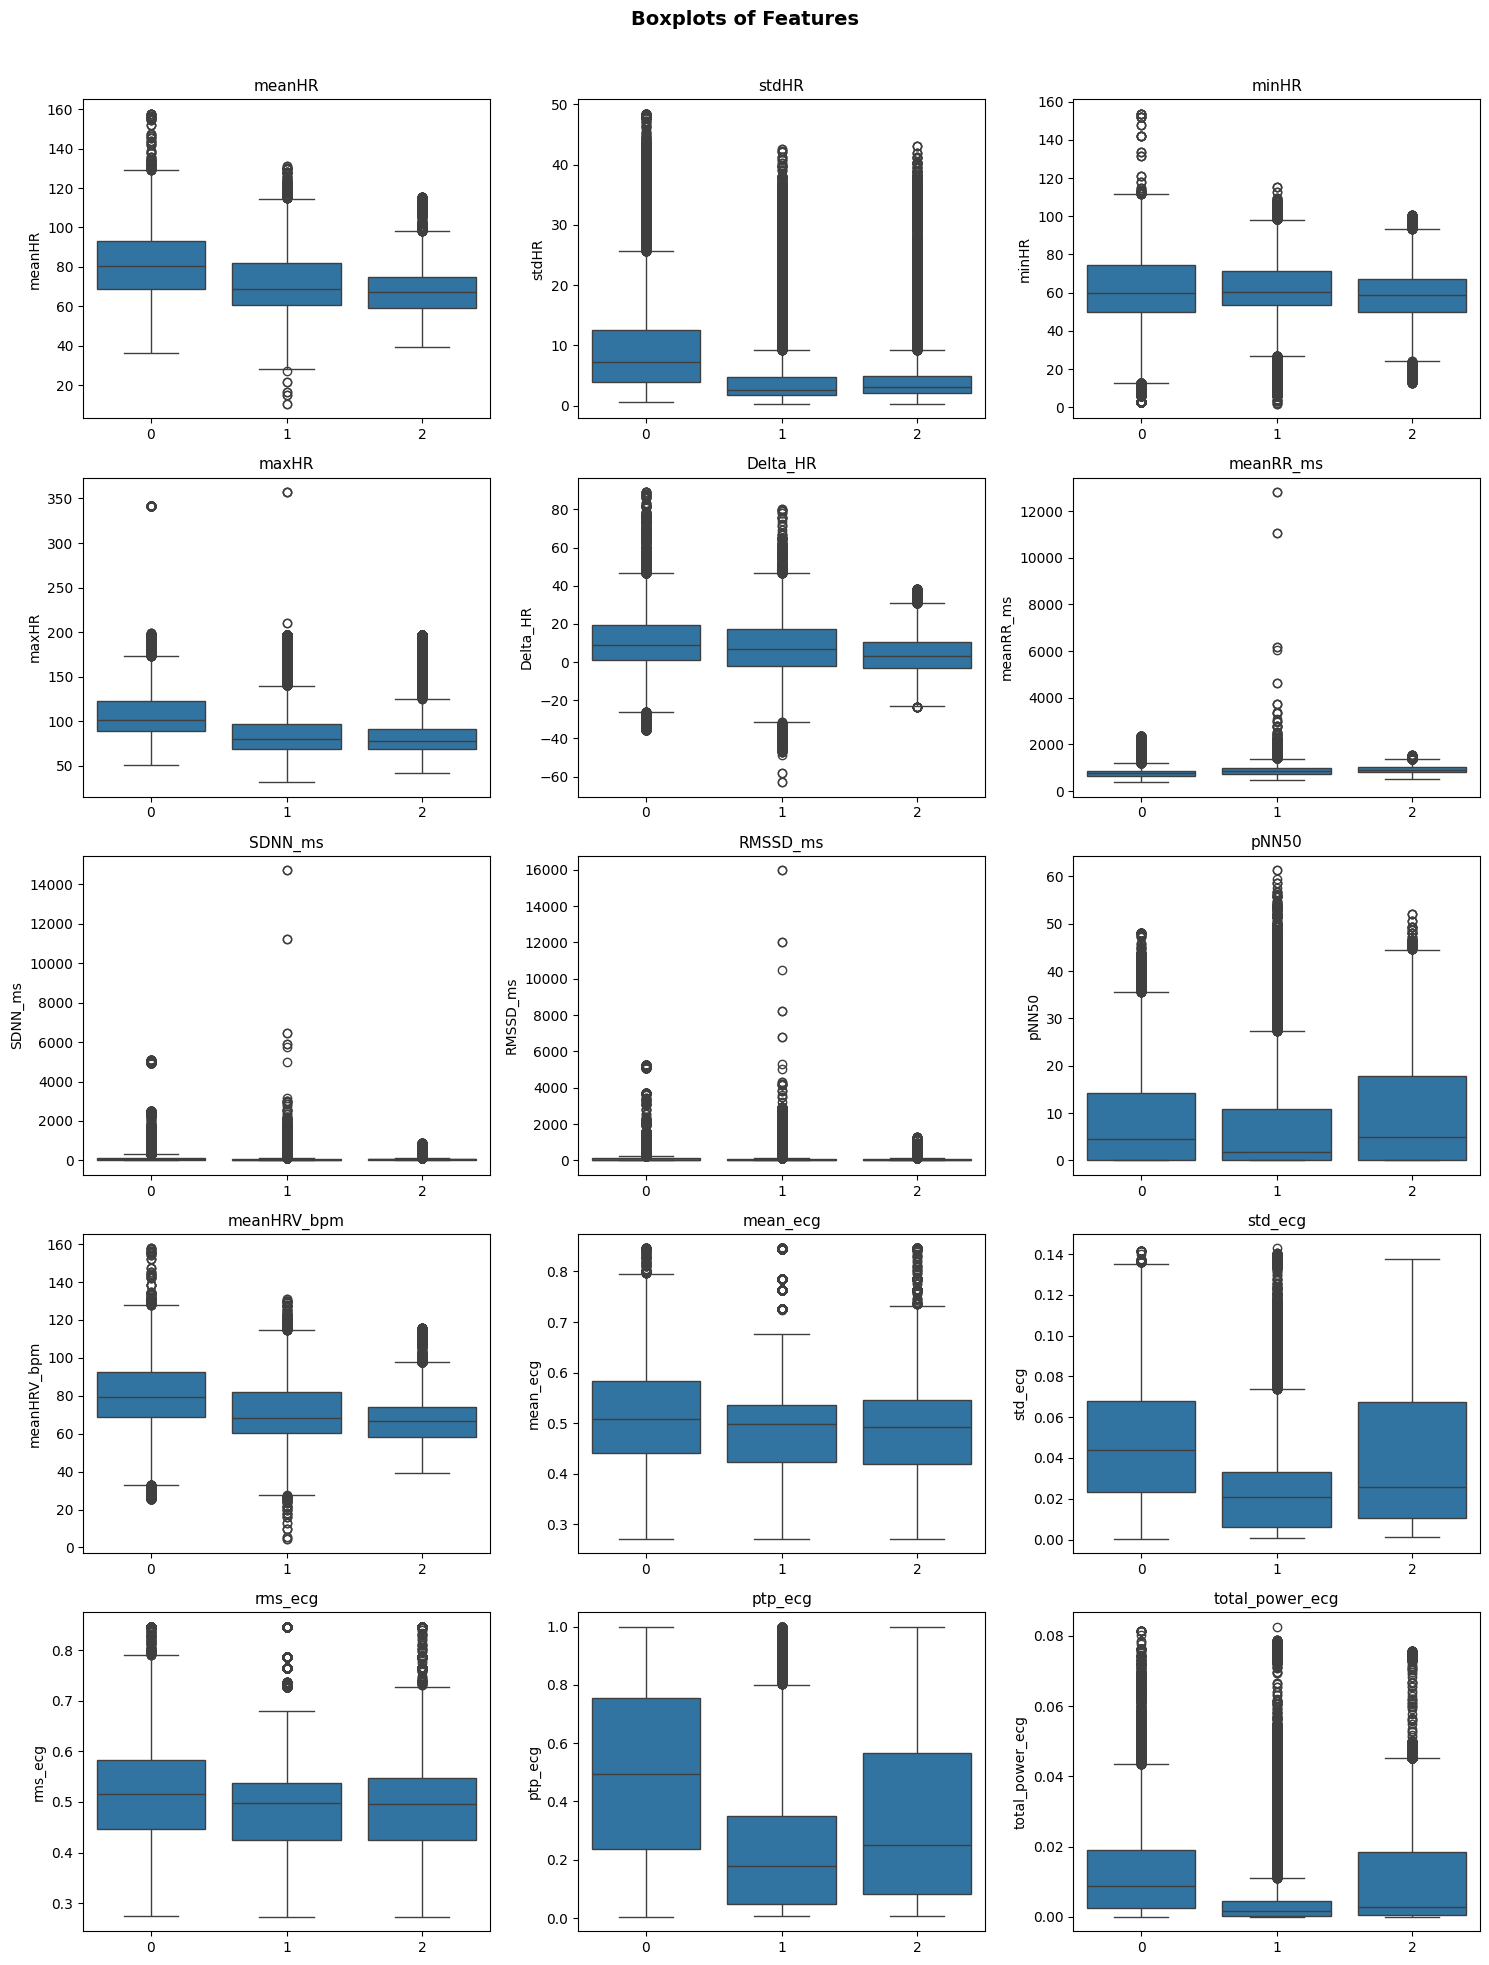

In [26]:
Plot_Boxplots(Train)

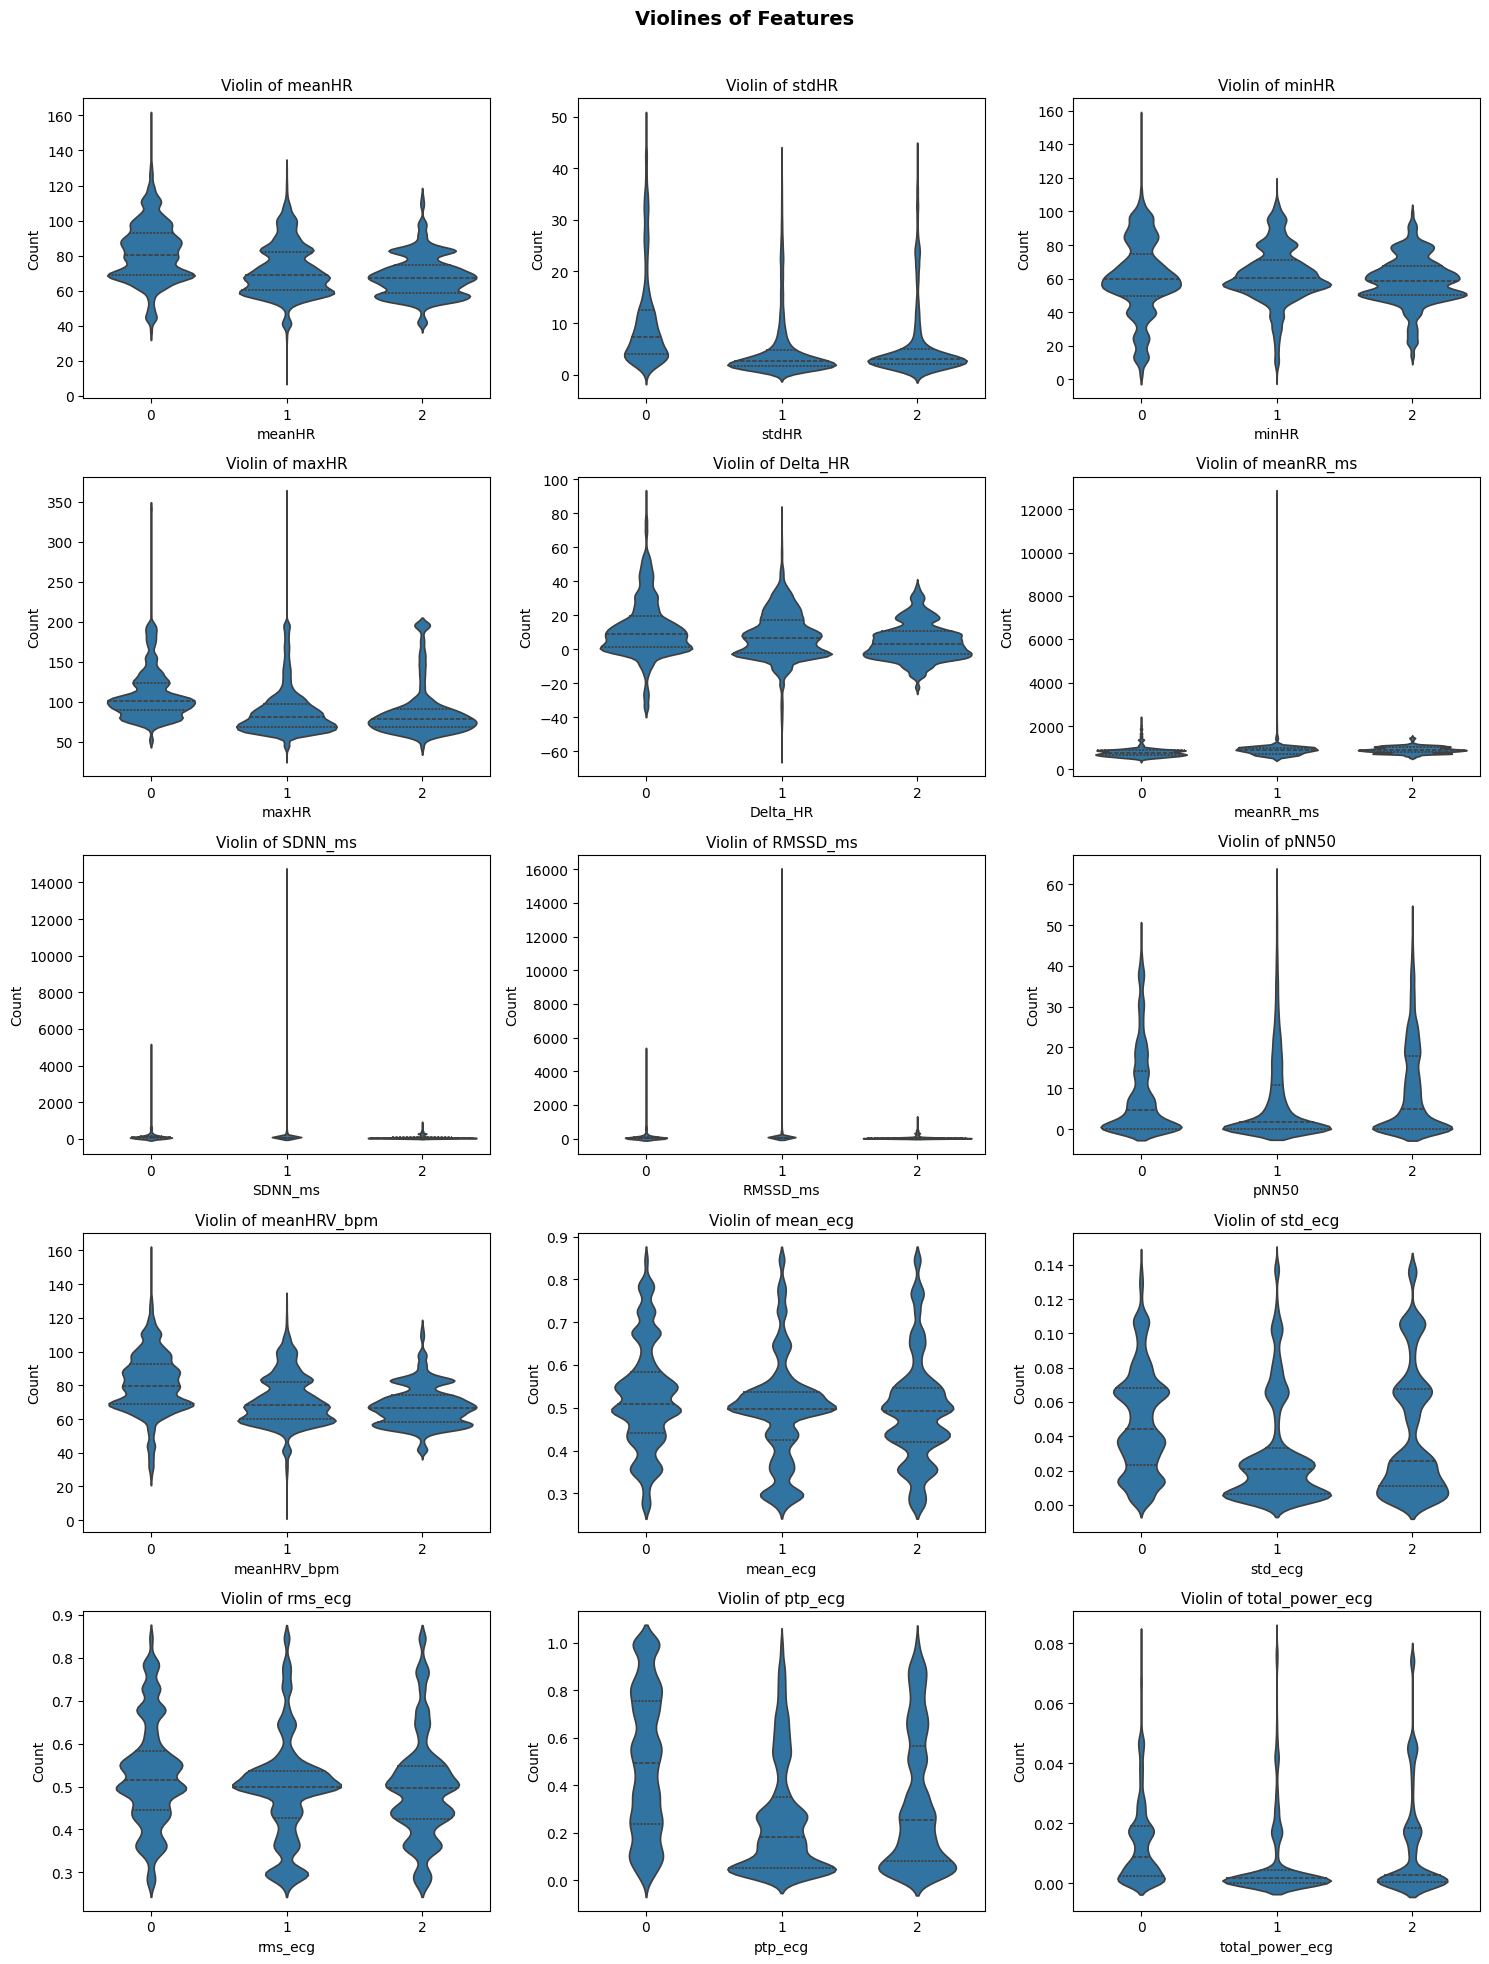

In [27]:
Plot_Violin(Train)

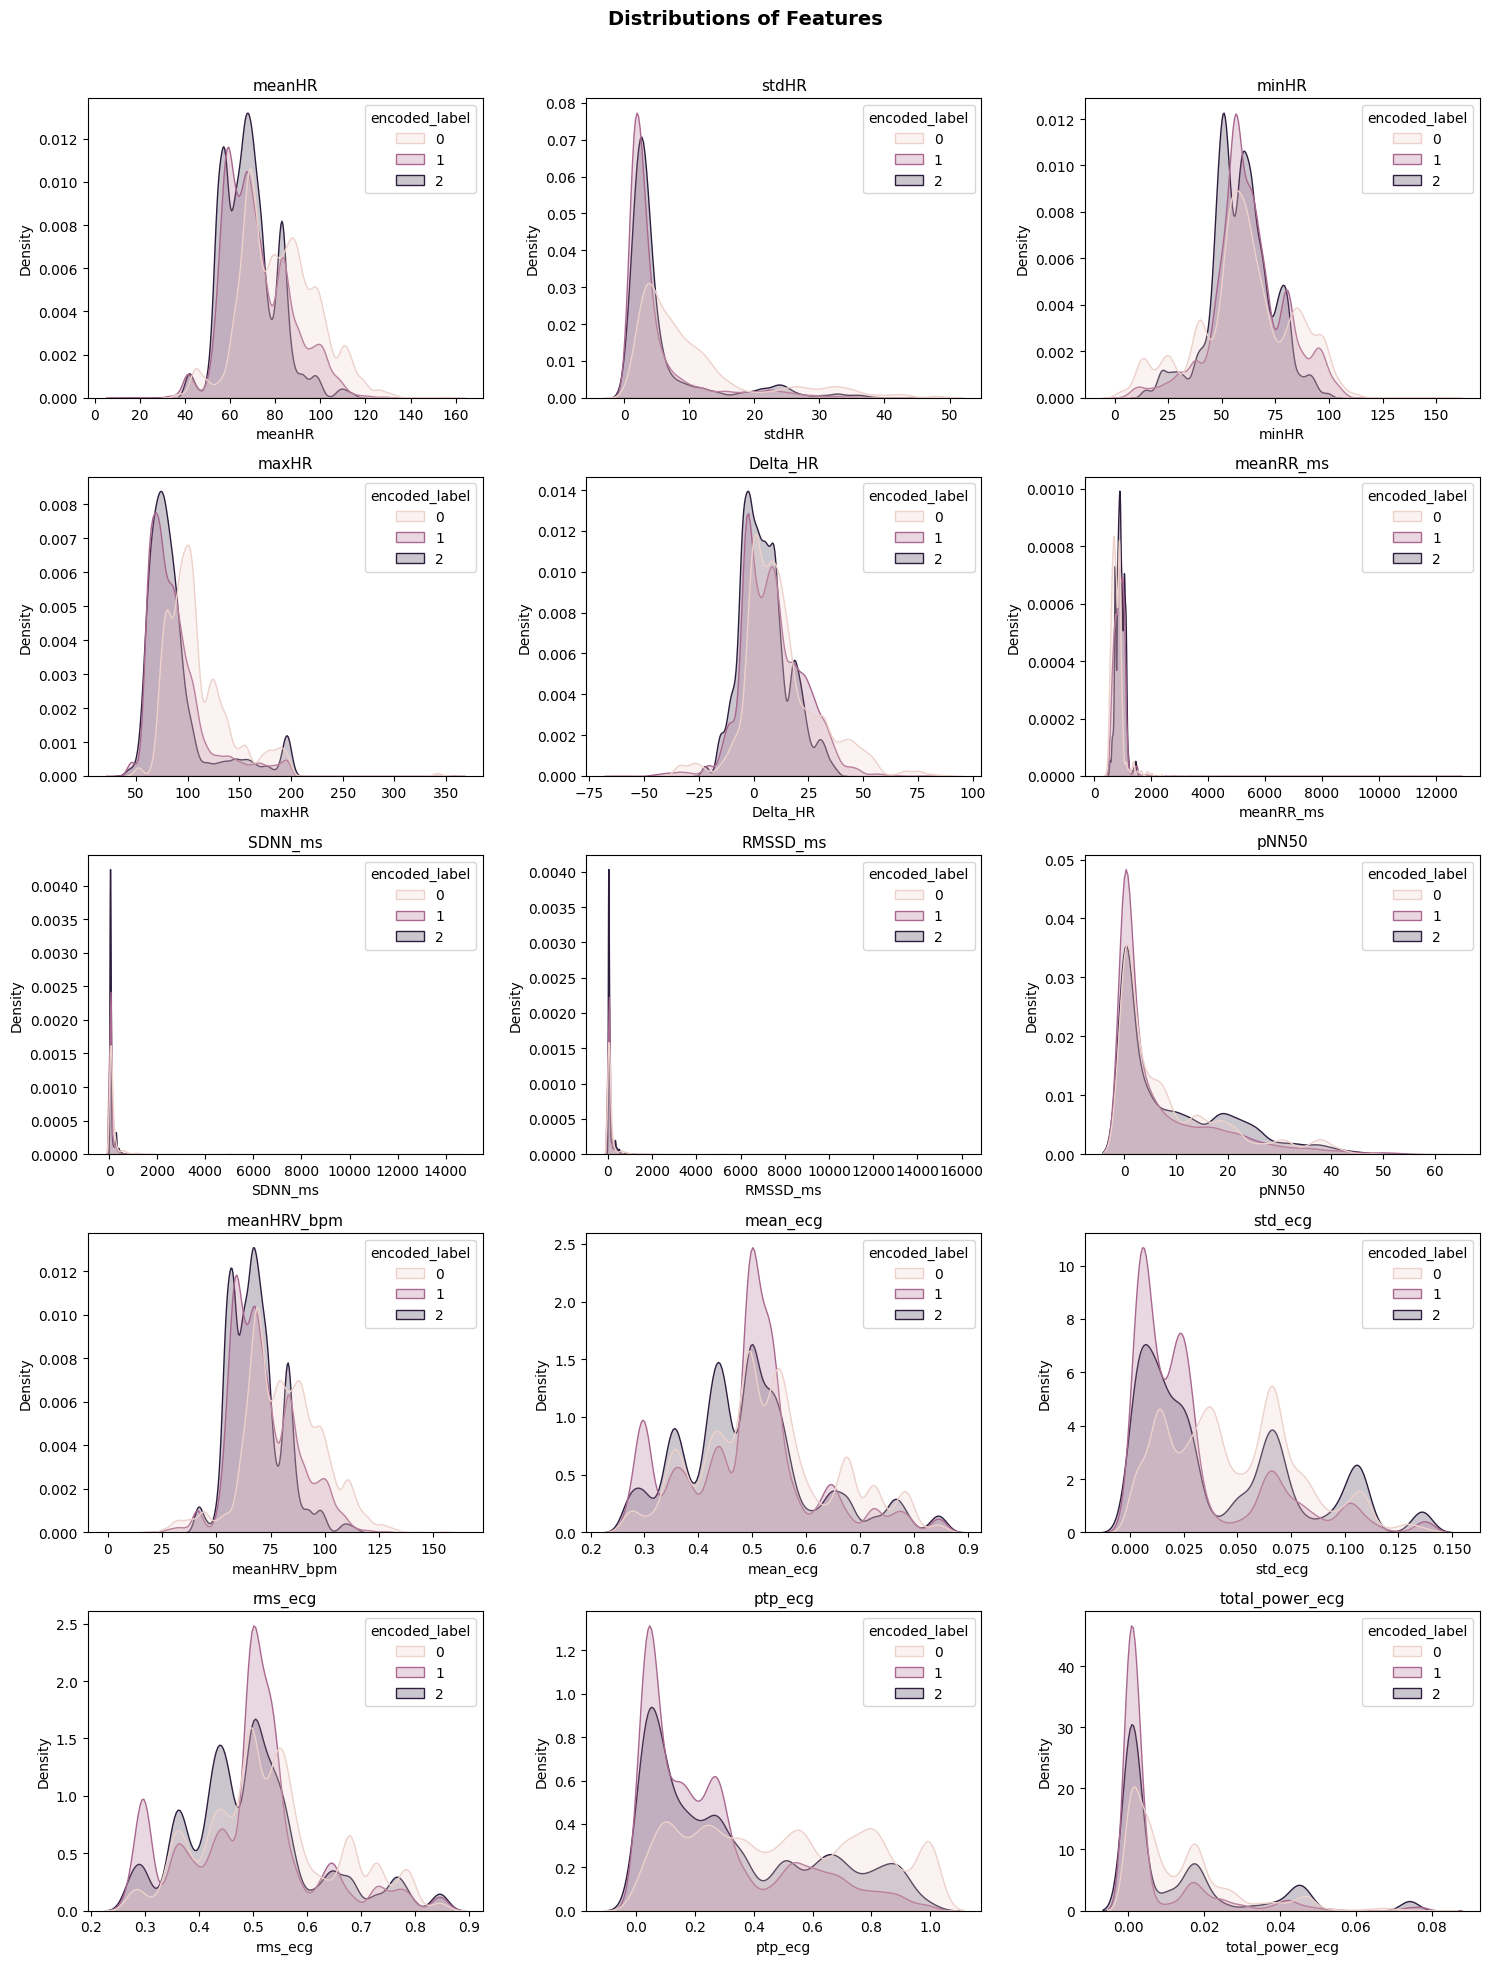

In [28]:
Plot_Distribution(Train)

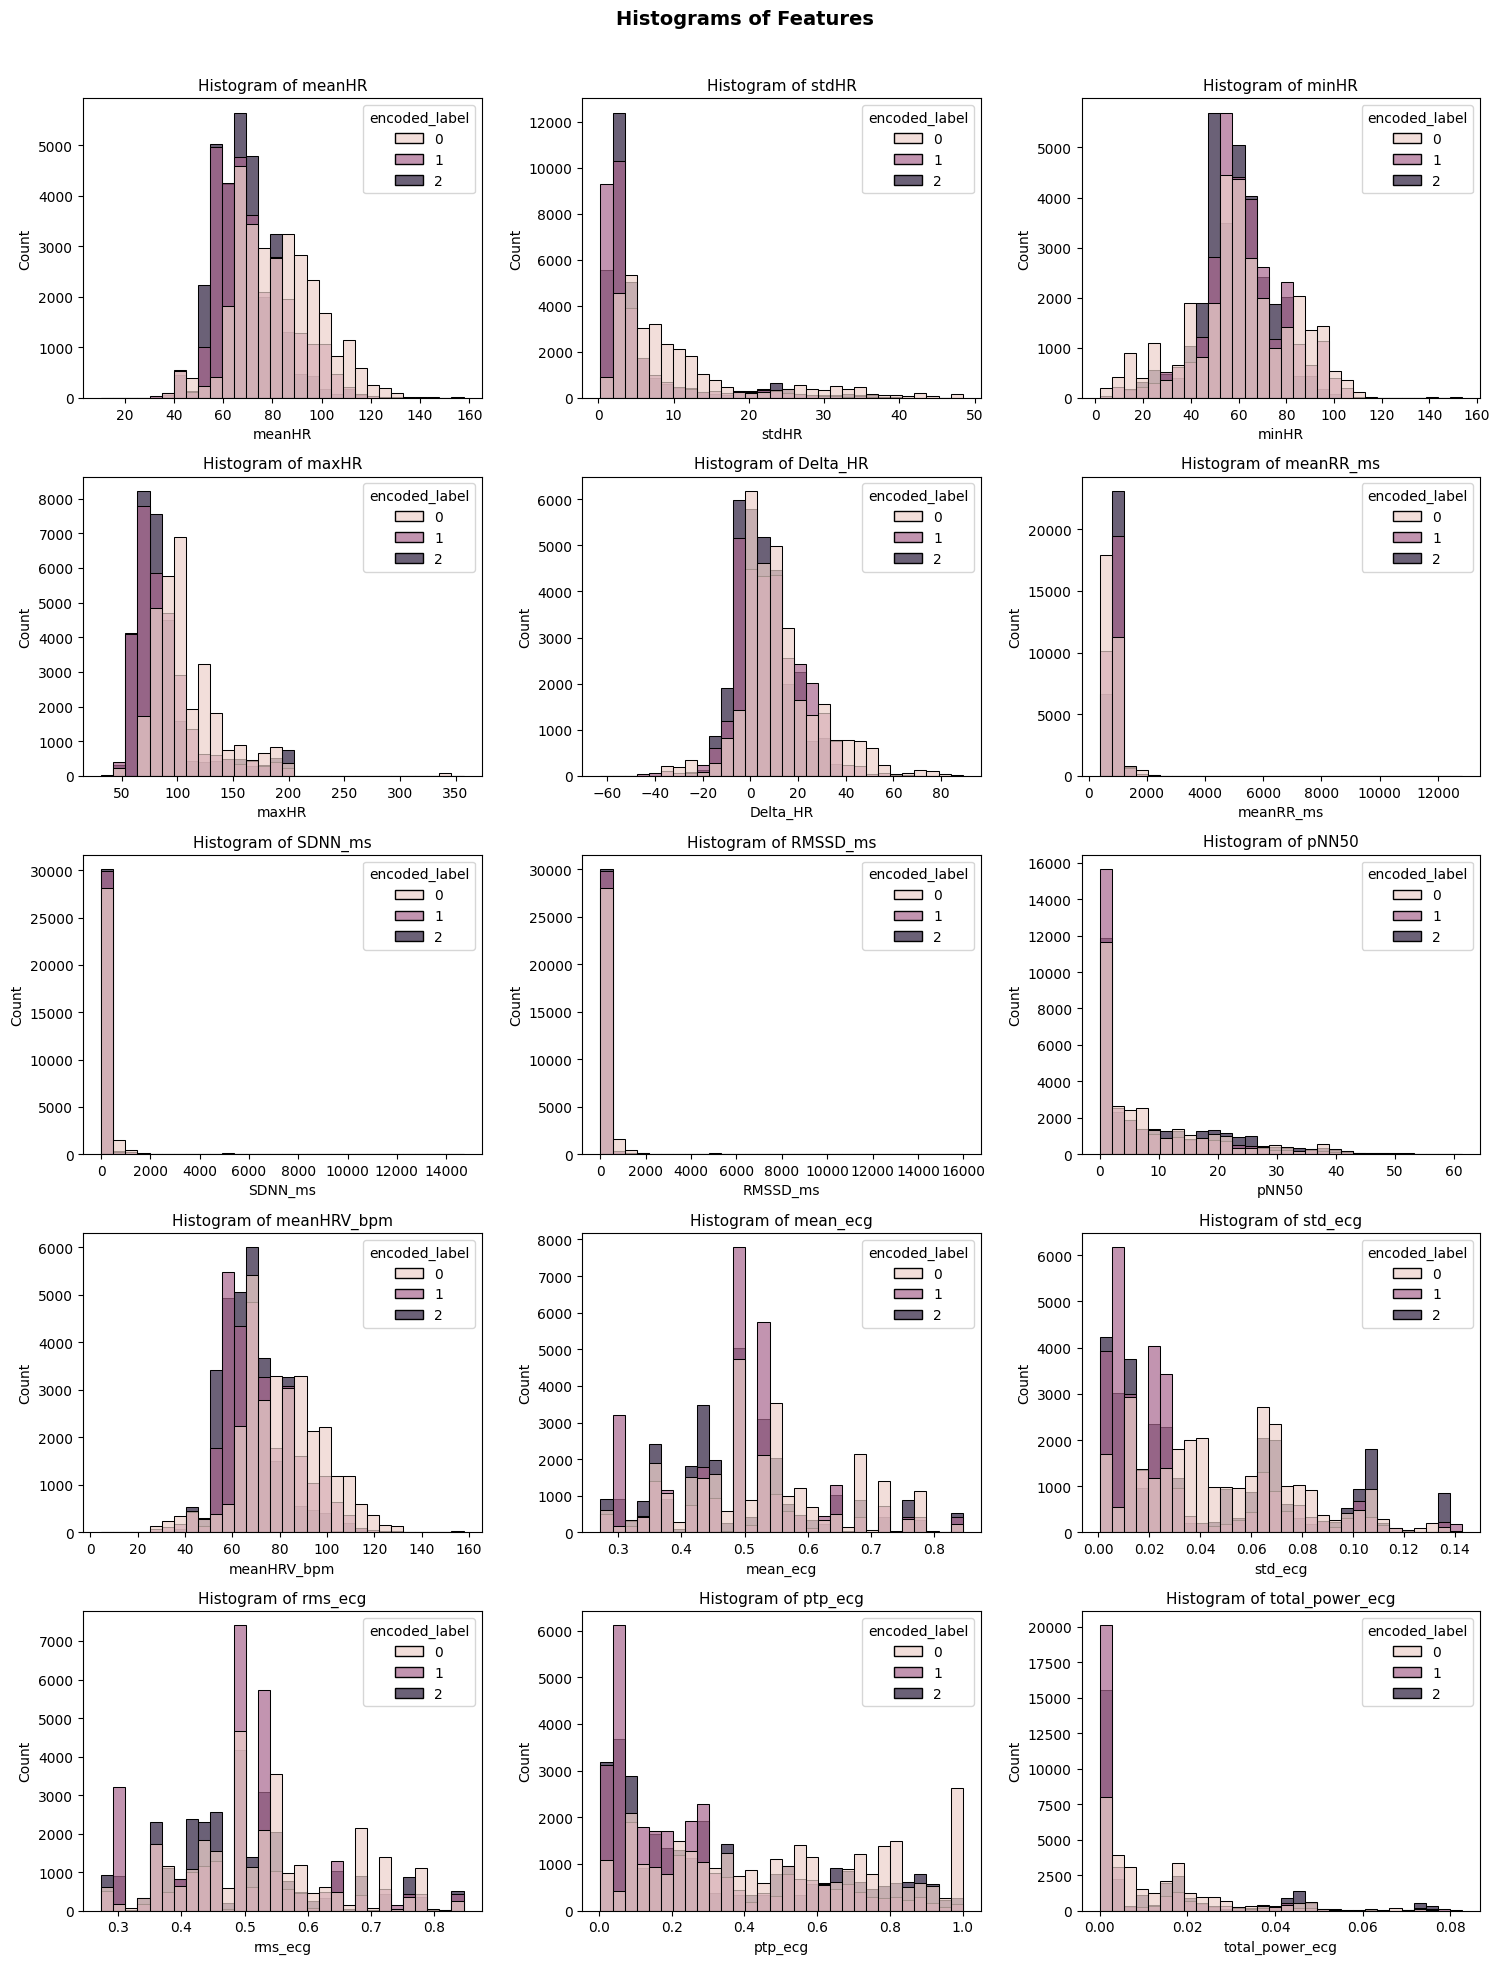

In [29]:
Plot_Histograms(Train)

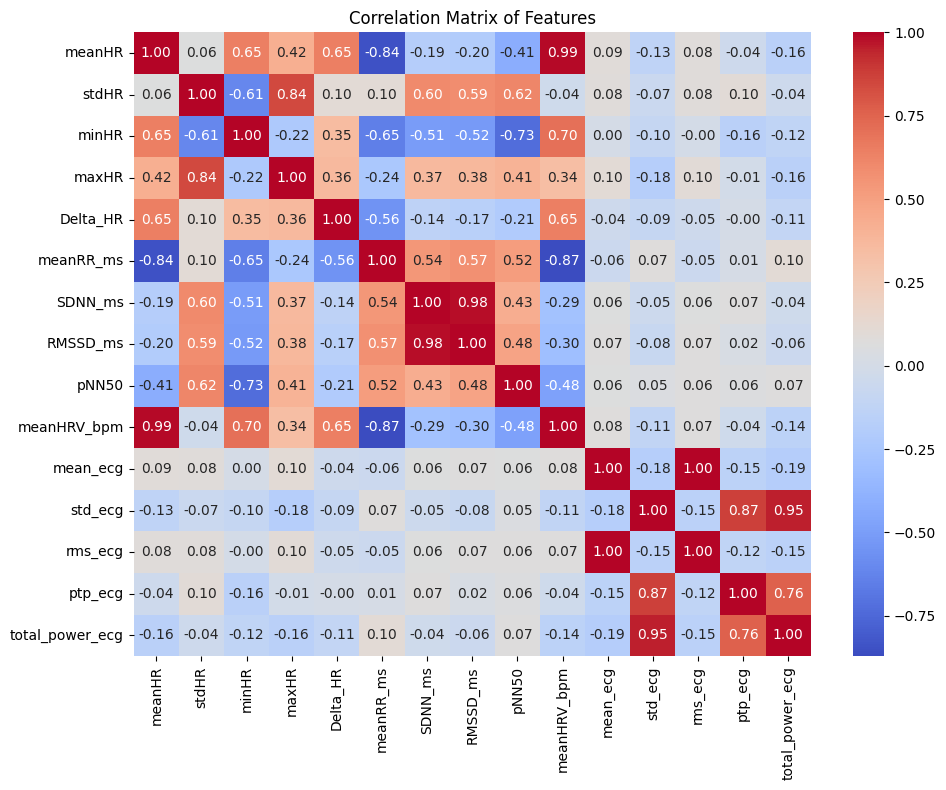

In [30]:
Plot_Correlation(Train)

In [31]:
Analysis_Feature(Train)

Analyzing 17 numeric features: ['meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms', 'RMSSD_ms', 'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg', 'bp_0_5_3_ecg', 'n_beats']

==== Feature: meanHR ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,0,36.135897,157.671817,81.765583,16.975517,80.454546,68.879701,93.030434
1,1,10.394373,131.063317,71.753047,14.842327,68.724567,60.421155,82.180656
2,2,39.167316,115.581437,68.301481,11.927603,67.225205,58.887363,74.665619


==== Feature: stdHR ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,0,0.632968,48.427319,10.729191,9.751619,7.228567,3.953722,12.608635
1,2,0.301975,43.134744,5.744474,7.182178,3.110479,2.143054,4.976637
2,1,0.260338,42.511739,4.895163,6.170734,2.644648,1.673338,4.702184


==== Feature: minHR ====


...

,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,0,9.157359e-07,0.081244,0.013681,0.014509,0.008696,0.002635,0.018982
1,2,6.888208e-06,0.075602,0.012560,0.017762,0.002670,0.000497,0.018335
2,1,2.570305e-06,0.082604,0.007518,0.014032,0.001712,0.000162,0.004503


==== Feature: bp_0_5_3_ecg ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,2,7.928181e-07,0.012879,0.001243,0.002393,0.000220,0.000021,0.001189
1,0,9.013184e-08,0.013102,0.001220,0.001765,0.000608,0.000187,0.001597
2,1,2.630665e-07,0.014322,0.000755,0.001920,0.000060,0.000015,0.000392


==== Feature: n_beats ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,0,5.0,156.0,80.149034,17.856200,79.0,68.0,91.994502
1,1,5.0,130.0,70.887970,15.057054,68.0,60.0,81.000000
2,2,39.0,115.0,67.448894,11.856240,66.0,58.0,73.576371


### Save

In [32]:
Train.to_csv('train.csv', index=False)
Test.to_csv('valid.csv', index=False)